# ITAI 2376 Demonstration  Notebook - A01 A Comparative Analysis of Machine Learning and Deep Learning Tools and Frameworks / Use case: Risk prediction for preterm labor / preterm birth 

**Topic:** PyTorch vs TensorFlow/Keras  
**Use case:** Dummy *preterm risk* classifier (synthetic data)  
**Note:** This is **not** a clinical model. The dataset is synthetic.


## 0) Optional installs
If you run this on a fresh environment, start here and install first. 


In [2]:
# Uncomment if needed:
# !pip install torch --quiet
# !pip install tensorflow --quiet


## 1) Creation of a small synthetic dataset
I used 3 features:
- age
- prior_preterm (0/1)
- cervix_length_mm

Label is generated from a hidden logistic rule.


In [3]:
import numpy as np

np.random.seed(0)

N = 300
age = np.random.uniform(18, 45, N)
prior_preterm = np.random.binomial(1, 0.20, N)
cervix_length_mm = np.random.uniform(15, 45, N)

X = np.stack([age, prior_preterm, cervix_length_mm], axis=1).astype(np.float32)

# Dummy risk rule: higher if prior_preterm=1 and cervix is shorter
logits = -5 + 1.5*prior_preterm - 0.10*(cervix_length_mm - 30) + 0.03*(age - 28)
p = 1 / (1 + np.exp(-logits))
y = (np.random.rand(N) < p).astype(np.float32)

# Standardize features 
X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-6)

# Train/test split
idx = np.arange(N)
np.random.shuffle(idx)
train_idx, test_idx = idx[:240], idx[240:]
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print('Train shape:', X_train.shape, y_train.shape)
print('Test shape:', X_test.shape, y_test.shape)
print('Positive rate (train):', y_train.mean())


Train shape: (240, 3) (240,)
Test shape: (60, 3) (60,)
Positive rate (train): 0.025


## 2) Demonstration A — PyTorch 
One linear layer = logistic regression. I trained for a few steps and print accuracy + example risk score.


In [4]:
import torch
import torch.nn as nn

torch.manual_seed(0)

Xtr = torch.tensor(X_train, dtype=torch.float32)
ytr = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

Xte = torch.tensor(X_test, dtype=torch.float32)
yte = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

model = nn.Linear(3, 1)  
loss_fn = nn.BCEWithLogitsLoss()
opt = torch.optim.SGD(model.parameters(), lr=0.1)

for epoch in range(200):
    opt.zero_grad()
    logits = model(Xtr)
    loss = loss_fn(logits, ytr)
    loss.backward()
    opt.step()

with torch.no_grad():
    probs = torch.sigmoid(model(Xte))
    preds = (probs >= 0.5).float()
    acc = (preds.eq(yte)).float().mean().item()

print('PyTorch test accuracy:', round(acc, 3))

# Example risk score
with torch.no_grad():
    sample_risk = torch.sigmoid(model(Xte[:1])).item()
print('PyTorch example risk score (0–1):', round(sample_risk, 3))


PyTorch test accuracy: 0.967
PyTorch example risk score (0–1): 0.071


## 3) Demonstration B — TensorFlow/Keras 
Same idea: one Dense layer with sigmoid.


In [5]:
import tensorflow as tf

tf.random.set_seed(0)

model_tf = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(3,))
])

model_tf.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_tf.fit(X_train, y_train, epochs=50, verbose=0)

loss, acc = model_tf.evaluate(X_test, y_test, verbose=0)
print('TensorFlow test accuracy:', round(float(acc), 3))

risk_tf = float(model_tf.predict(X_test[:1], verbose=0)[0, 0])
print('TensorFlow example risk score (0–1):', round(risk_tf, 3))


/Users/jirimusil/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


TensorFlow test accuracy: 0.967
TensorFlow example risk score (0–1): 0.047


## 4) Visualization 

I added simple plots, feature distributions, ROC/AUC, and a confusion matrix, to help you visually understand the synthetic data patterns and compare PyTorch vs TensorFlow model performance.

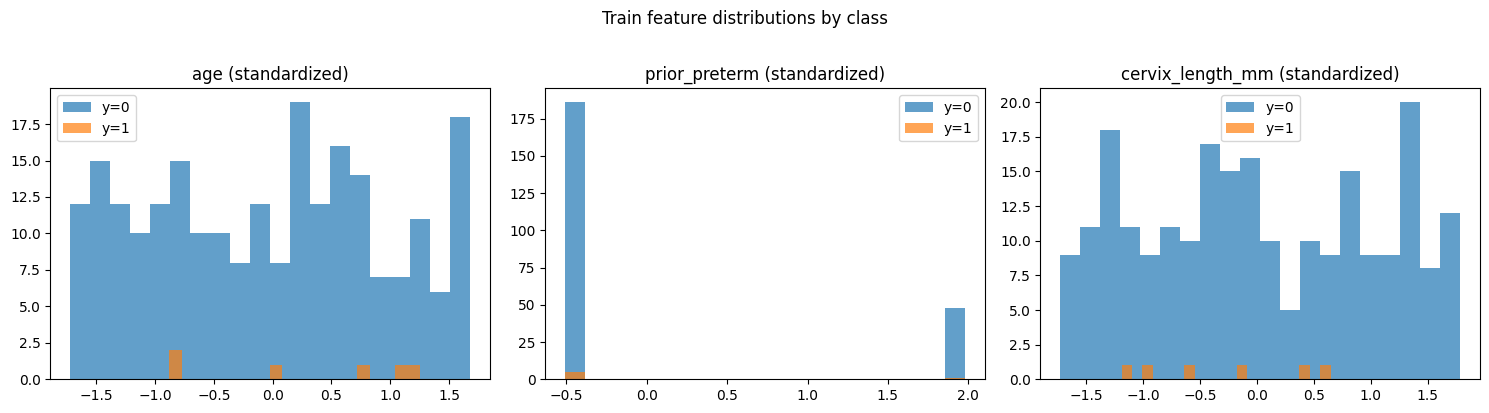

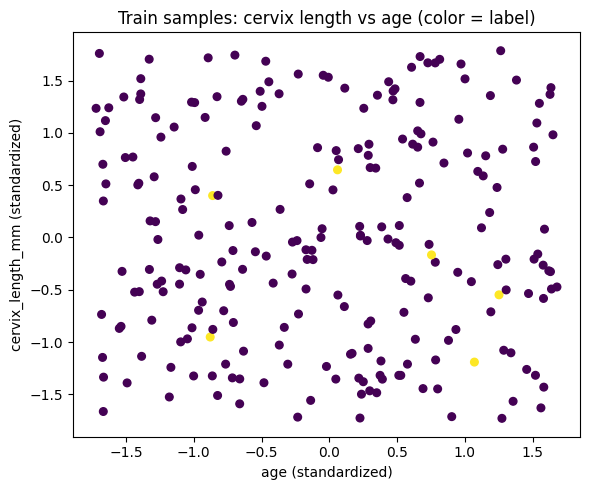

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- Helper: safely get probabilities even if variables were cleared ---
def get_probs_pytorch():
    # prefers existing `probs` from your notebook, otherwise recompute
    if "probs" in globals():
        return probs.detach().cpu().numpy().ravel()
    else:
        with torch.no_grad():
            return torch.sigmoid(model(Xte)).detach().cpu().numpy().ravel()

def get_probs_tf():
    return model_tf.predict(X_test, verbose=0).ravel()

probs_pt = get_probs_pytorch()
probs_tf = get_probs_tf()

y_test_np = np.array(y_test).astype(int)
y_train_np = np.array(y_train).astype(int)

# --- 1) Feature distributions by class (train set) ---
feature_names = ["age (standardized)", "prior_preterm (standardized)", "cervix_length_mm (standardized)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for j, ax in enumerate(axes):
    ax.hist(X_train[y_train_np == 0, j], bins=20, alpha=0.7, label="y=0")
    ax.hist(X_train[y_train_np == 1, j], bins=20, alpha=0.7, label="y=1")
    ax.set_title(feature_names[j])
    ax.legend()
plt.suptitle("Train feature distributions by class", y=1.02)
plt.tight_layout()
plt.show()

# --- 2) Scatter: age vs cervix length (train), colored by label ---
plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 2], c=y_train_np, s=30)
plt.xlabel("age (standardized)")
plt.ylabel("cervix_length_mm (standardized)")
plt.title("Train samples: cervix length vs age (color = label)")
plt.tight_layout()
plt.show()

# --- 3) ROC + AUC (manual implementation to avoid sklearn dependency) ---
def roc_auc_manual(y_true, y_score):
    order = np.argsort(-y_score)
    y_true = y_true[order]
    y_score = y_score[order]

    P = (y_true == 1).sum()
    N = (y_true == 0).sum()

    tpr, fpr = [0.0],
